# General Analysis

This sections is to have a general analysis that includes not only the target authors, but also data from the coauthors extracted

## All Authors Analysis

This notebook uses `filtered_all_df.csv` and `filtered_all_df_corr.csv` to analyze the full author group.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — Config & shared helpers for the "all authors" analysis
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, gaussian_kde

ACTUAL_Y    = 2025
PLOT_START  = 2020
PLOT_END    = 2025
TOPIC_COL   = "primary_topic"
JOURNAL_COL = "journal_display_name"
DATA_PATH   = "filtered_all_df_corr.csv"   # adjust if needed

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 130})

def load_all():
    df = pd.read_csv(DATA_PATH)
    df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce")
    cit_cols = [c for c in df.columns if c.startswith("citations_year_")]
    df[cit_cols] = df[cit_cols].apply(pd.to_numeric, errors="coerce")hi
    df["cit_2yr"] = df["citations_year_0"].fillna(0) + df["citations_year_1"].fillna(0)
    return df, cit_cols

def eligibility_threshold(df, group_col, id_col="article_id"):
    counts = df.groupby(group_col)[id_col].nunique()
    min_n  = int(np.floor(counts.mean())) + 1
    return counts[counts >= min_n].index, min_n, counts
filtered_all_df_corr=pd.read_csv("/home/ramir713/PublicationAnalysis/data/filtered_TargetA_df_corr.csv")
print("Config loaded. Call load_all() in each cell.")

Config loaded. Call load_all() in each cell.


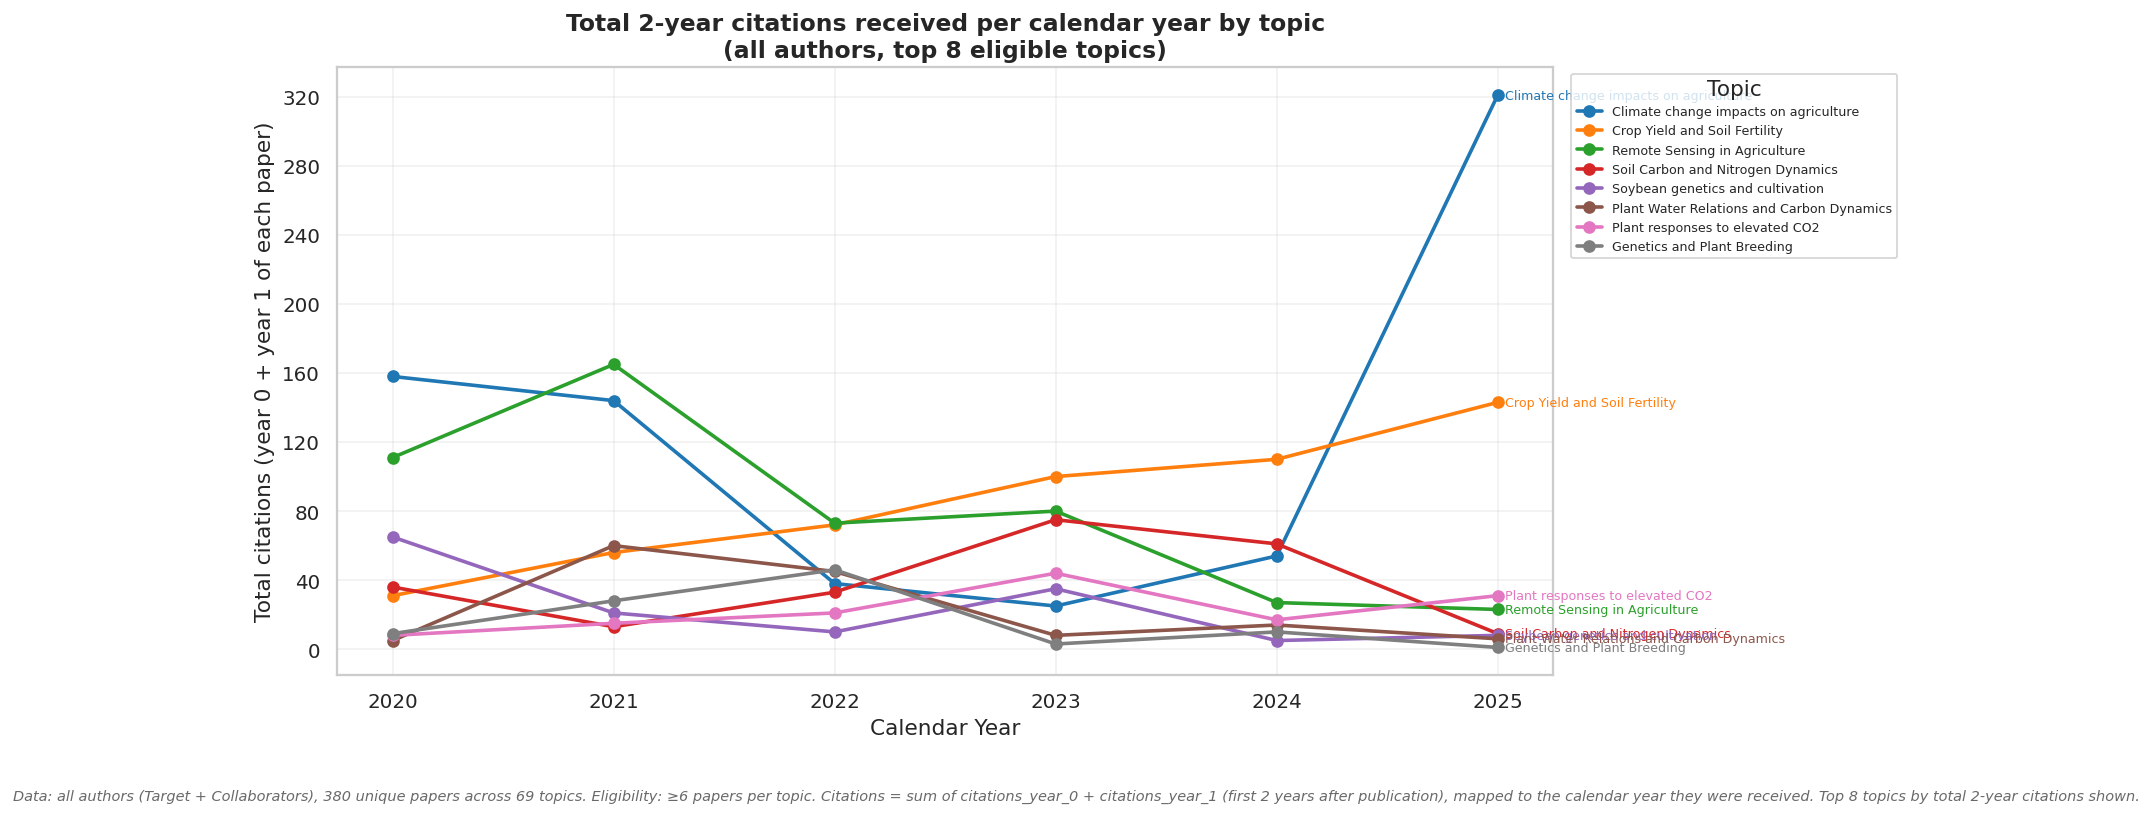

Eligibility threshold: ≥6 papers | Topics eligible: 16/69


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 (all authors) — Total 2-yr citations received per calendar year by topic
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

ACTUAL_Y = 2025; PLOT_START = 2020; PLOT_END = 2025; TOP_N = 8
TOPIC_COL = "primary_topic"

df = filtered_all_df_corr.copy()
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")
cit_cols = [c for c in df.columns if c.startswith("citations_year_")]
df[cit_cols] = df[cit_cols].apply(pd.to_numeric, errors="coerce")

# --- Melt to long, restrict to 2-year window (offset 0 and 1) ---------------
long = (
    df[["article_id", "publication_year", TOPIC_COL] + cit_cols]
    .dropna(subset=[TOPIC_COL, "publication_year"])
    .melt(id_vars=["article_id", "publication_year", TOPIC_COL],
          value_vars=cit_cols, var_name="cit_col", value_name="citations")
)
long["offset"]        = long["cit_col"].str.extract(r"(\d+)$").astype(int)
long["calendar_year"] = long["publication_year"].astype(int) + long["offset"]
long["citations"]     = long["citations"].fillna(0)

# Keep only the 2-year window and the plot range
long = long[long["offset"].isin([0, 1])]
long = long[(long["calendar_year"] >= PLOT_START) & (long["calendar_year"] <= PLOT_END)]

# --- Eligibility: topics with >= floor(mean)+1 unique papers -----------------
paper_counts = df.dropna(subset=[TOPIC_COL]).groupby(TOPIC_COL)["article_id"].nunique()
min_papers   = int(np.floor(paper_counts.mean())) + 1
eligible     = paper_counts[paper_counts >= min_papers].index
long         = long[long[TOPIC_COL].isin(eligible)]

# --- Aggregate ---------------------------------------------------------------
agg = long.groupby([TOPIC_COL, "calendar_year"])["citations"].sum().reset_index()

top_topics = (
    agg.groupby(TOPIC_COL)["citations"].sum()
    .nlargest(TOP_N).index.tolist()
)
agg = agg[agg[TOPIC_COL].isin(top_topics)]

pivot = (
    agg.pivot(index="calendar_year", columns=TOPIC_COL, values="citations")
    .reindex(columns=top_topics)
    .reindex(range(PLOT_START, PLOT_END + 1))
    .fillna(0)
)

# --- Plot --------------------------------------------------------------------
palette     = sns.color_palette("tab10", n_colors=TOP_N)
topic_color = dict(zip(top_topics, palette))

fig, ax = plt.subplots(figsize=(13, 6))
for topic in top_topics:
    ax.plot(pivot.index, pivot[topic], marker="o", linewidth=2,
            label=topic, color=topic_color[topic])
    last_val = pivot[topic].iloc[-1]
    ax.annotate(topic, xy=(pivot.index[-1], last_val),
                xytext=(4, 0), textcoords="offset points",
                fontsize=7, color=topic_color[topic], va="center")

ax.set_title(f"Total 2-year citations received per calendar year by topic\n(all authors, top {TOP_N} eligible topics)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Calendar Year")
ax.set_ylabel("Total citations (year 0 + year 1 of each paper)")
ax.set_xticks(range(PLOT_START, PLOT_END + 1))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.grid(alpha=0.25)

note = (
    f"Data: all authors (Target + Collaborators), {df['article_id'].nunique()} unique papers across "
    f"{df[TOPIC_COL].nunique()} topics. Eligibility: ≥{min_papers} papers per topic. "
    f"Citations = sum of citations_year_0 + citations_year_1 (first 2 years after publication), "
    f"mapped to the calendar year they were received. Top {TOP_N} topics by total 2-year citations shown."
)
fig.text(0.5, -0.04, note, ha="center", fontsize=8, color="dimgray", style="italic")
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()
print(f"Eligibility threshold: ≥{min_papers} papers | Topics eligible: {len(eligible)}/{len(paper_counts)}")

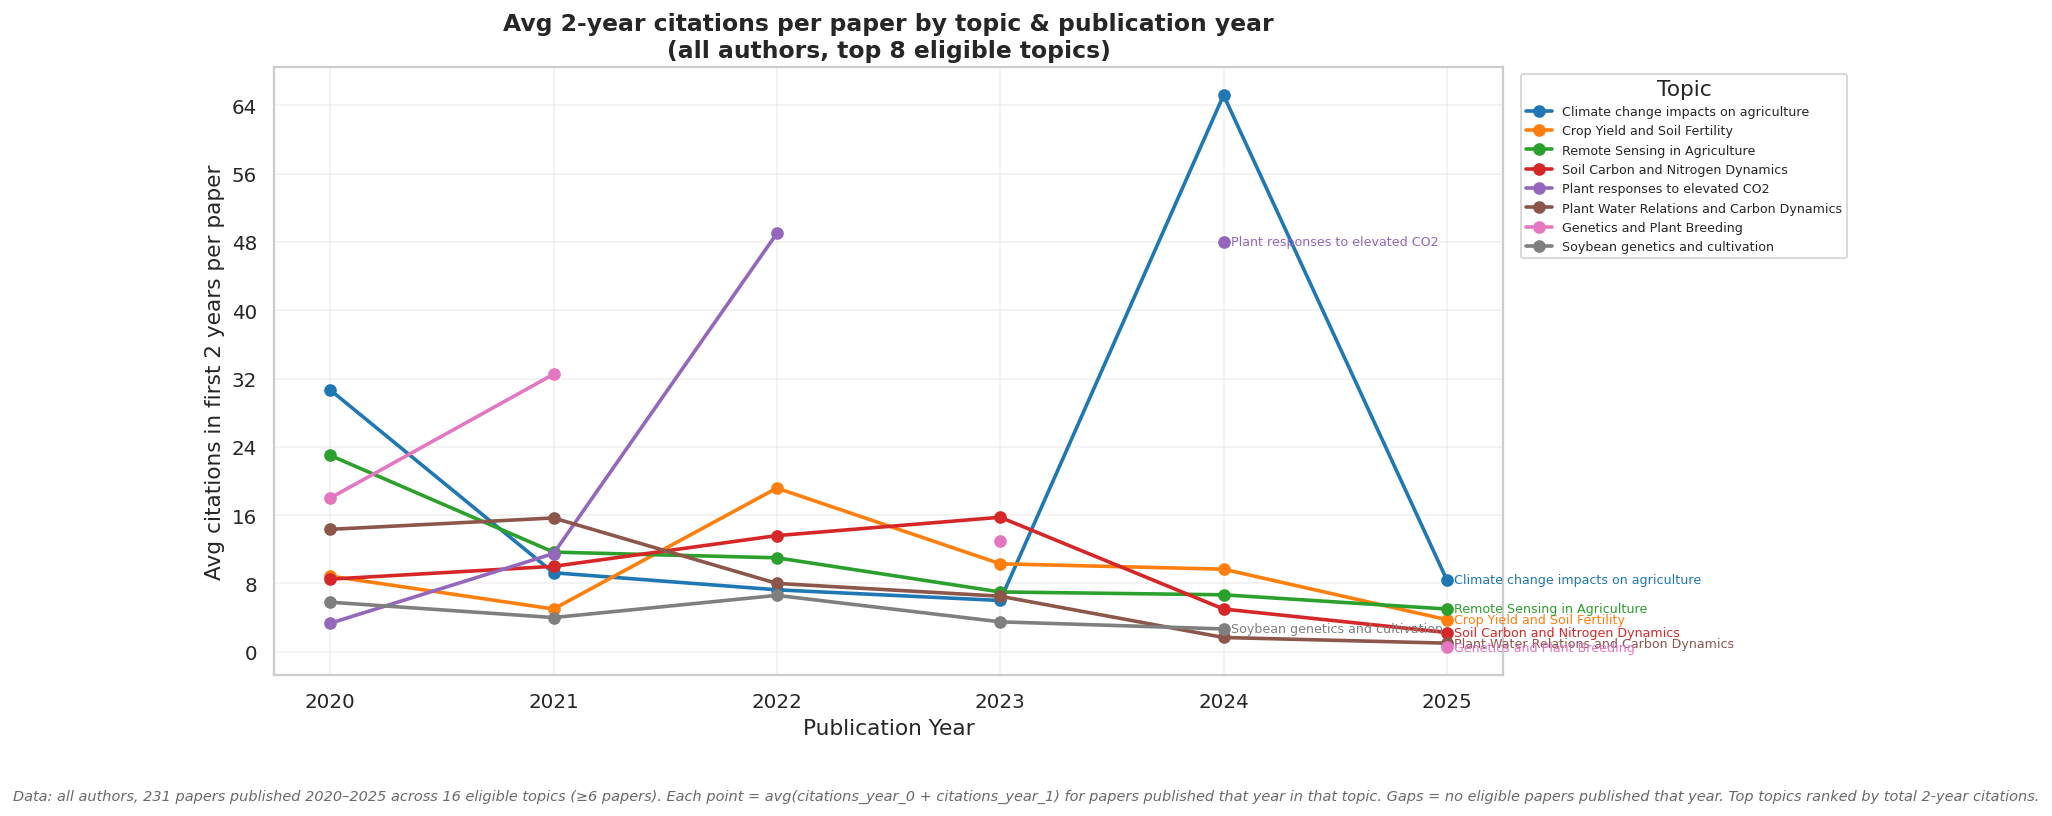

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 (all authors) — Avg 2-yr citations per paper by publication year & topic
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

PLOT_START = 2020; PLOT_END = 2025; TOP_N = 8
TOPIC_COL  = "primary_topic"

df = filtered_all_df_corr.copy()
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")
df["cit_2yr"] = (
    pd.to_numeric(df["citations_year_0"], errors="coerce").fillna(0)
    + pd.to_numeric(df["citations_year_1"], errors="coerce").fillna(0)
)

paper = (
    df[["article_id", TOPIC_COL, "publication_year", "cit_2yr"]]
    .dropna(subset=[TOPIC_COL, "publication_year"])
    .drop_duplicates(subset="article_id")
)
paper = paper[(paper["publication_year"] >= PLOT_START) & (paper["publication_year"] <= PLOT_END)]

# Eligibility
counts     = df.dropna(subset=[TOPIC_COL]).groupby(TOPIC_COL)["article_id"].nunique()
min_papers = int(np.floor(counts.mean())) + 1
eligible   = counts[counts >= min_papers].index
paper      = paper[paper[TOPIC_COL].isin(eligible)]

stats_df = (
    paper.groupby([TOPIC_COL, "publication_year"])
    .agg(total_cit_2yr=("cit_2yr", "sum"), n_papers=("article_id", "nunique"))
    .reset_index()
)
stats_df["avg_cit_2yr"] = stats_df["total_cit_2yr"] / stats_df["n_papers"].clip(lower=1)

top_topics = (
    stats_df.groupby(TOPIC_COL)["total_cit_2yr"].sum()
    .nlargest(TOP_N).index.tolist()
)
stats_df = stats_df[stats_df[TOPIC_COL].isin(top_topics)]

# Reindex to expose gaps (no papers that year = NaN, not zero)
full_idx  = pd.MultiIndex.from_product([top_topics, range(PLOT_START, PLOT_END + 1)],
                                        names=[TOPIC_COL, "publication_year"])
stats_df  = stats_df.set_index([TOPIC_COL, "publication_year"]).reindex(full_idx).reset_index()

palette     = sns.color_palette("tab10", n_colors=TOP_N)
topic_color = dict(zip(top_topics, palette))

fig, ax = plt.subplots(figsize=(13, 6))
for topic in top_topics:
    grp = stats_df[stats_df[TOPIC_COL] == topic].sort_values("publication_year")
    ax.plot(grp["publication_year"], grp["avg_cit_2yr"], marker="o",
            linewidth=2, label=topic, color=topic_color[topic])
    last = grp.dropna(subset=["avg_cit_2yr"]).iloc[-1] if not grp.dropna(subset=["avg_cit_2yr"]).empty else None
    if last is not None:
        ax.annotate(topic, xy=(last["publication_year"], last["avg_cit_2yr"]),
                    xytext=(4, 0), textcoords="offset points",
                    fontsize=7, color=topic_color[topic], va="center")

ax.set_title(f"Avg 2-year citations per paper by topic & publication year\n(all authors, top {TOP_N} eligible topics)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Avg citations in first 2 years per paper")
ax.set_xticks(range(PLOT_START, PLOT_END + 1))
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.grid(alpha=0.25)

note = (
    f"Data: all authors, {paper['article_id'].nunique()} papers published {PLOT_START}–{PLOT_END} "
    f"across {len(eligible)} eligible topics (≥{min_papers} papers). "
    "Each point = avg(citations_year_0 + citations_year_1) for papers published that year in that topic. "
    "Gaps = no eligible papers published that year. Top topics ranked by total 2-year citations."
)
fig.text(0.5, -0.04, note, ha="center", fontsize=8, color="dimgray", style="italic")
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

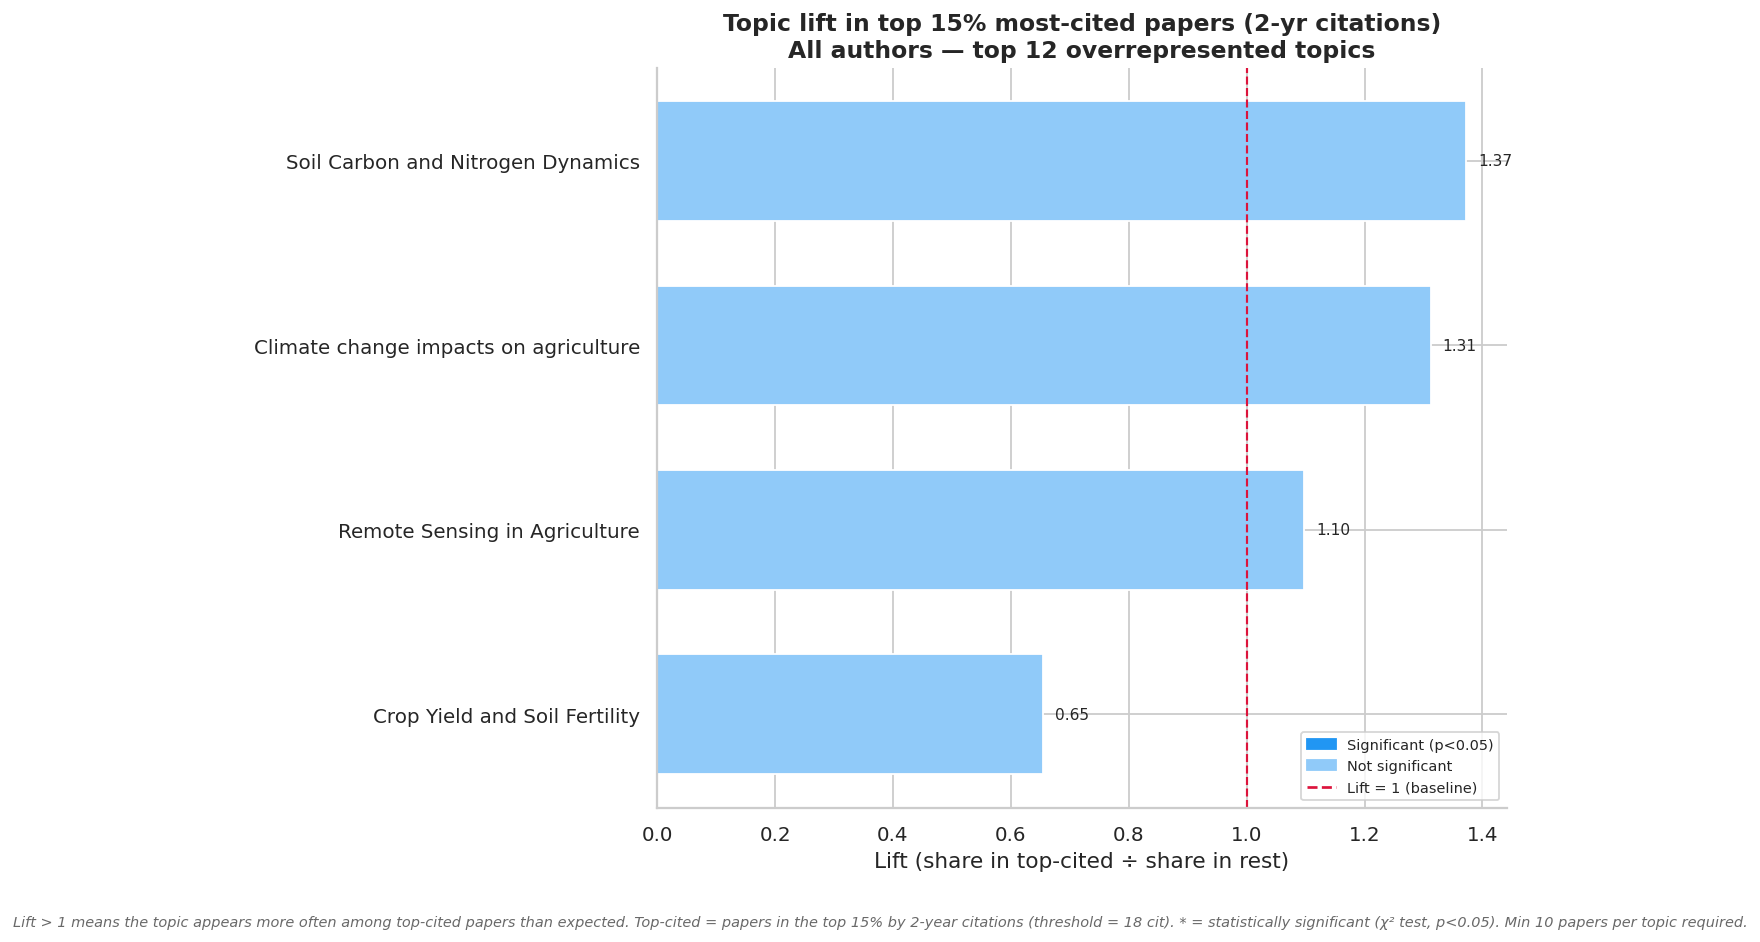

                                topic     lift  top_n   top_pct  rest_pct  p_value  significant
    Soil Carbon and Nitrogen Dynamics 1.372549      5 16.666667 12.142857 0.711227        False
Climate change impacts on agriculture 1.312500      9 30.000000 22.857143 0.551995        False
        Remote Sensing in Agriculture 1.098039      8 26.666667 24.285714 0.967169        False
        Crop Yield and Soil Fertility 0.654971      8 26.666667 40.714286 0.218766        False


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 (all authors) — Topic lift: overrepresentation in top-cited papers
# Answers: which topics punch above their weight in citations?
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency

TOP_PERCENTILE = 0.15   # top 15% = "highly cited"
MIN_PAPERS     = 10     # min papers per topic to include
TOP_K          = 12     # topics to show in chart
TOPIC_COL      = "primary_topic"

df = filtered_all_df_corr.copy()
df["cit_2yr"] = (
    pd.to_numeric(df["citations_year_0"], errors="coerce").fillna(0)
    + pd.to_numeric(df["citations_year_1"], errors="coerce").fillna(0)
)
df = df.dropna(subset=[TOPIC_COL, "cit_2yr"]).drop_duplicates(subset="article_id")

# Filter low-frequency topics
topic_counts = df[TOPIC_COL].value_counts()
df = df[df[TOPIC_COL].isin(topic_counts[topic_counts >= MIN_PAPERS].index)]

threshold = df["cit_2yr"].quantile(1 - TOP_PERCENTILE)
top_df    = df[df["cit_2yr"] >= threshold].copy()
rest_df   = df[df["cit_2yr"] <  threshold].copy()

# Only topics with ≥5 papers in top set
eligible = top_df[TOPIC_COL].value_counts()
eligible = eligible[eligible >= 5].index
top_df   = top_df[top_df[TOPIC_COL].isin(eligible)]
rest_df  = rest_df[rest_df[TOPIC_COL].isin(eligible)]

all_topics = sorted(eligible)
top_counts  = top_df[TOPIC_COL].value_counts()
rest_counts = rest_df[TOPIC_COL].value_counts()
top_pct     = top_counts.reindex(all_topics, fill_value=0) / len(top_df) * 100
rest_pct    = rest_counts.reindex(all_topics, fill_value=0) / max(len(rest_df), 1) * 100
lift        = (top_pct / rest_pct.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

results = []
for topic in all_topics:
    a = top_counts.get(topic, 0);  b = len(top_df) - a
    c = rest_counts.get(topic, 0); d = len(rest_df) - c
    try:
        _, p, _, _ = chi2_contingency([[a, b], [c, d]])
    except Exception:
        p = np.nan
    results.append({"topic": topic, "lift": lift.get(topic, np.nan),
                    "top_pct": top_pct.get(topic, 0),
                    "rest_pct": rest_pct.get(topic, 0),
                    "top_n": a, "p_value": p})

res = (pd.DataFrame(results)
       .dropna(subset=["lift"])
       .sort_values("lift", ascending=False)
       .head(TOP_K))
res["significant"] = res["p_value"] < 0.05
res = res.sort_values("lift")

colors = ["#2196F3" if sig else "#90CAF9" for sig in res["significant"]]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(res["topic"], res["lift"], color=colors, edgecolor="white", height=0.65)
ax.axvline(1.0, color="crimson", linestyle="--", linewidth=1.2, label="No overrepresentation (lift=1)")
for bar, (_, row) in zip(bars, res.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{row['lift']:.2f}{'*' if row['significant'] else ''}",
            va="center", fontsize=8.5)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#2196F3", label="Significant (p<0.05)"),
    Patch(color="#90CAF9", label="Not significant"),
    plt.Line2D([0], [0], color="crimson", linestyle="--", label="Lift = 1 (baseline)")
], fontsize=8, loc="lower right")

ax.set_title(f"Topic lift in top {int(TOP_PERCENTILE*100)}% most-cited papers (2-yr citations)\n"
             f"All authors — top {TOP_K} overrepresented topics", fontsize=13, fontweight="bold")
ax.set_xlabel("Lift (share in top-cited ÷ share in rest)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

note = (
    f"Lift > 1 means the topic appears more often among top-cited papers than expected. "
    f"Top-cited = papers in the top {int(TOP_PERCENTILE*100)}% by 2-year citations (threshold = {threshold:.0f} cit). "
    f"* = statistically significant (χ² test, p<0.05). Min {MIN_PAPERS} papers per topic required."
)
fig.text(0.5, -0.03, note, ha="center", fontsize=8, color="dimgray", style="italic")
plt.subplots_adjust(bottom=0.1)
plt.show()

print(res[["topic", "lift", "top_n", "top_pct", "rest_pct", "p_value", "significant"]]
      .sort_values("lift", ascending=False).to_string(index=False))

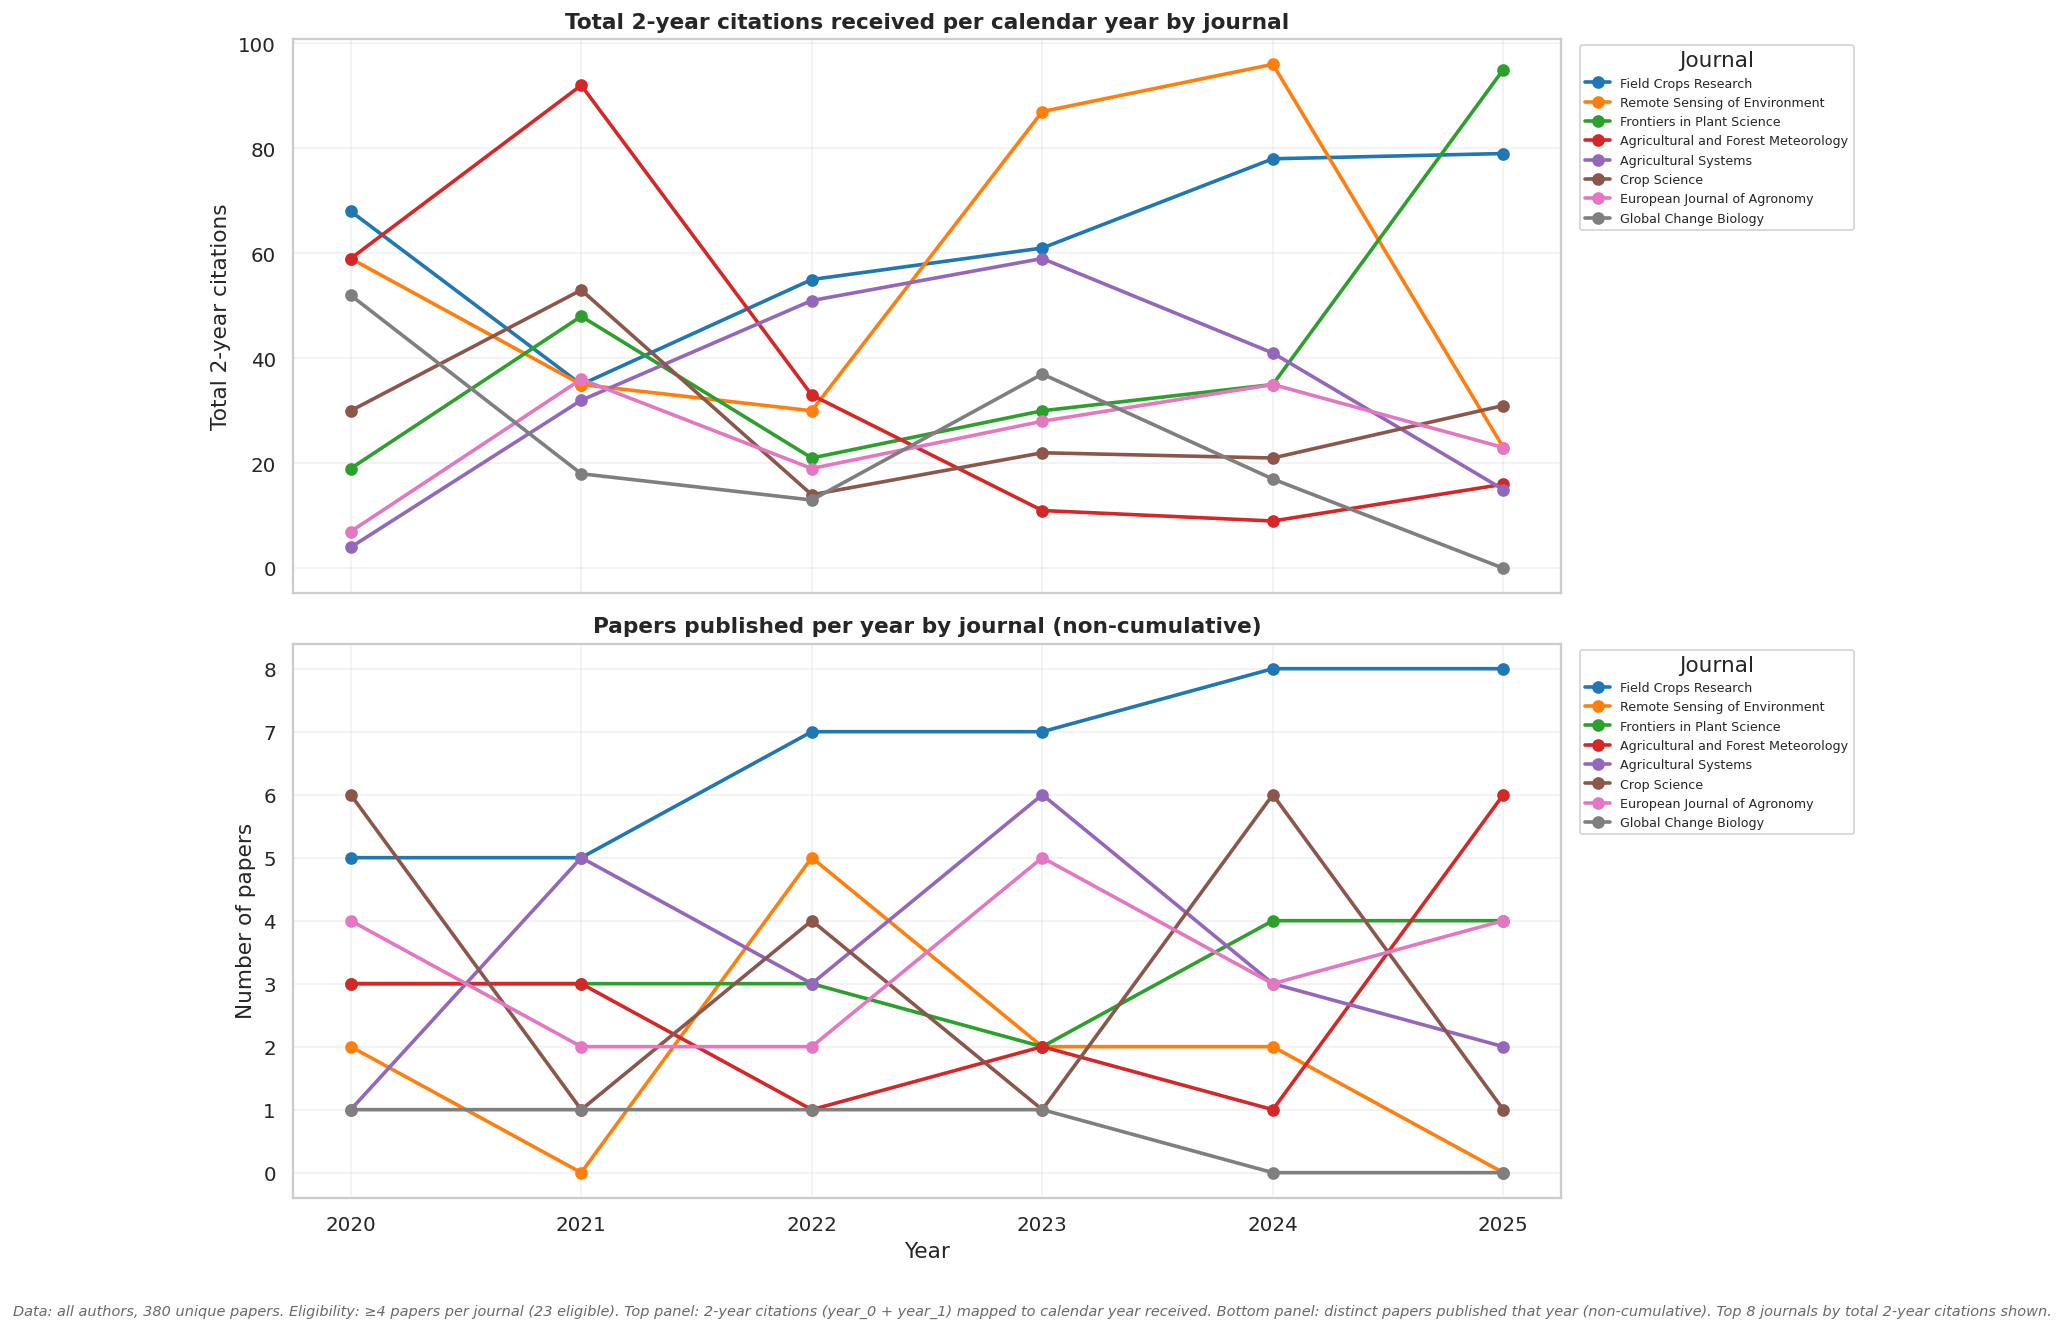

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 (all authors) — Journal trends: citations received & papers published
# Two-panel plot for direct comparison
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

PLOT_START = 2020; PLOT_END = 2025; TOP_N = 8
JOURNAL_COL = "journal_display_name"

df = filtered_all_df_corr.copy()
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")
cit_cols = [c for c in df.columns if c.startswith("citations_year_")]
df[cit_cols] = df[cit_cols].apply(pd.to_numeric, errors="coerce")

# --- Citation long format (2-year window only) --------------------------------
long = (
    df[["article_id", "publication_year", JOURNAL_COL] + cit_cols]
    .dropna(subset=[JOURNAL_COL, "publication_year"])
    .melt(id_vars=["article_id", "publication_year", JOURNAL_COL],
          value_vars=cit_cols, var_name="cit_col", value_name="citations")
)
long["offset"]        = long["cit_col"].str.extract(r"(\d+)$").astype(int)
long["calendar_year"] = long["publication_year"].astype(int) + long["offset"]
long["citations"]     = long["citations"].fillna(0)
long = long[long["offset"].isin([0, 1])]
long = long[(long["calendar_year"] >= PLOT_START) & (long["calendar_year"] <= PLOT_END)]

# --- Papers published per year -----------------------------------------------
pub = (
    df.dropna(subset=[JOURNAL_COL, "publication_year"])
    .drop_duplicates(subset="article_id")
)
pub = pub[(pub["publication_year"] >= PLOT_START) & (pub["publication_year"] <= PLOT_END)]

# Eligibility on overall unique papers
jnl_counts = df.dropna(subset=[JOURNAL_COL]).groupby(JOURNAL_COL)["article_id"].nunique()
min_papers  = int(np.floor(jnl_counts.mean())) + 1
eligible    = jnl_counts[jnl_counts >= min_papers].index

long = long[long[JOURNAL_COL].isin(eligible)]
pub  = pub[pub[JOURNAL_COL].isin(eligible)]

cit_agg = long.groupby([JOURNAL_COL, "calendar_year"])["citations"].sum().reset_index()
pub_agg = pub.groupby([JOURNAL_COL, "publication_year"])["article_id"].nunique().reset_index(name="n_papers")

top_journals = (
    cit_agg.groupby(JOURNAL_COL)["citations"].sum()
    .nlargest(TOP_N).index.tolist()
)

cit_pivot = (
    cit_agg[cit_agg[JOURNAL_COL].isin(top_journals)]
    .pivot(index="calendar_year", columns=JOURNAL_COL, values="citations")
    .reindex(columns=top_journals).reindex(range(PLOT_START, PLOT_END + 1)).fillna(0)
)
pub_pivot = (
    pub_agg[pub_agg[JOURNAL_COL].isin(top_journals)]
    .pivot(index="publication_year", columns=JOURNAL_COL, values="n_papers")
    .reindex(columns=top_journals).reindex(range(PLOT_START, PLOT_END + 1)).fillna(0)
)

palette     = sns.color_palette("tab10", n_colors=TOP_N)
jnl_color   = dict(zip(top_journals, palette))

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

for journal in top_journals:
    c = jnl_color[journal]
    axes[0].plot(cit_pivot.index, cit_pivot[journal], marker="o", linewidth=2, color=c, label=journal)
    axes[1].plot(pub_pivot.index, pub_pivot[journal], marker="o", linewidth=2, color=c, label=journal)

axes[0].set_title("Total 2-year citations received per calendar year by journal", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Total 2-year citations")
axes[0].grid(alpha=0.25)
axes[0].legend(title="Journal", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

axes[1].set_title("Papers published per year by journal (non-cumulative)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Number of papers")
axes[1].set_xlabel("Year")
axes[1].set_xticks(range(PLOT_START, PLOT_END + 1))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].grid(alpha=0.25)
axes[1].legend(title="Journal", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

note = (
    f"Data: all authors, {df['article_id'].nunique()} unique papers. "
    f"Eligibility: ≥{min_papers} papers per journal ({len(eligible)} eligible). "
    "Top panel: 2-year citations (year_0 + year_1) mapped to calendar year received. "
    "Bottom panel: distinct papers published that year (non-cumulative). "
    f"Top {TOP_N} journals by total 2-year citations shown."
)
fig.text(0.5, -0.02, note, ha="center", fontsize=8, color="dimgray", style="italic")
plt.tight_layout()
plt.subplots_adjust(bottom=0.07)
plt.show()

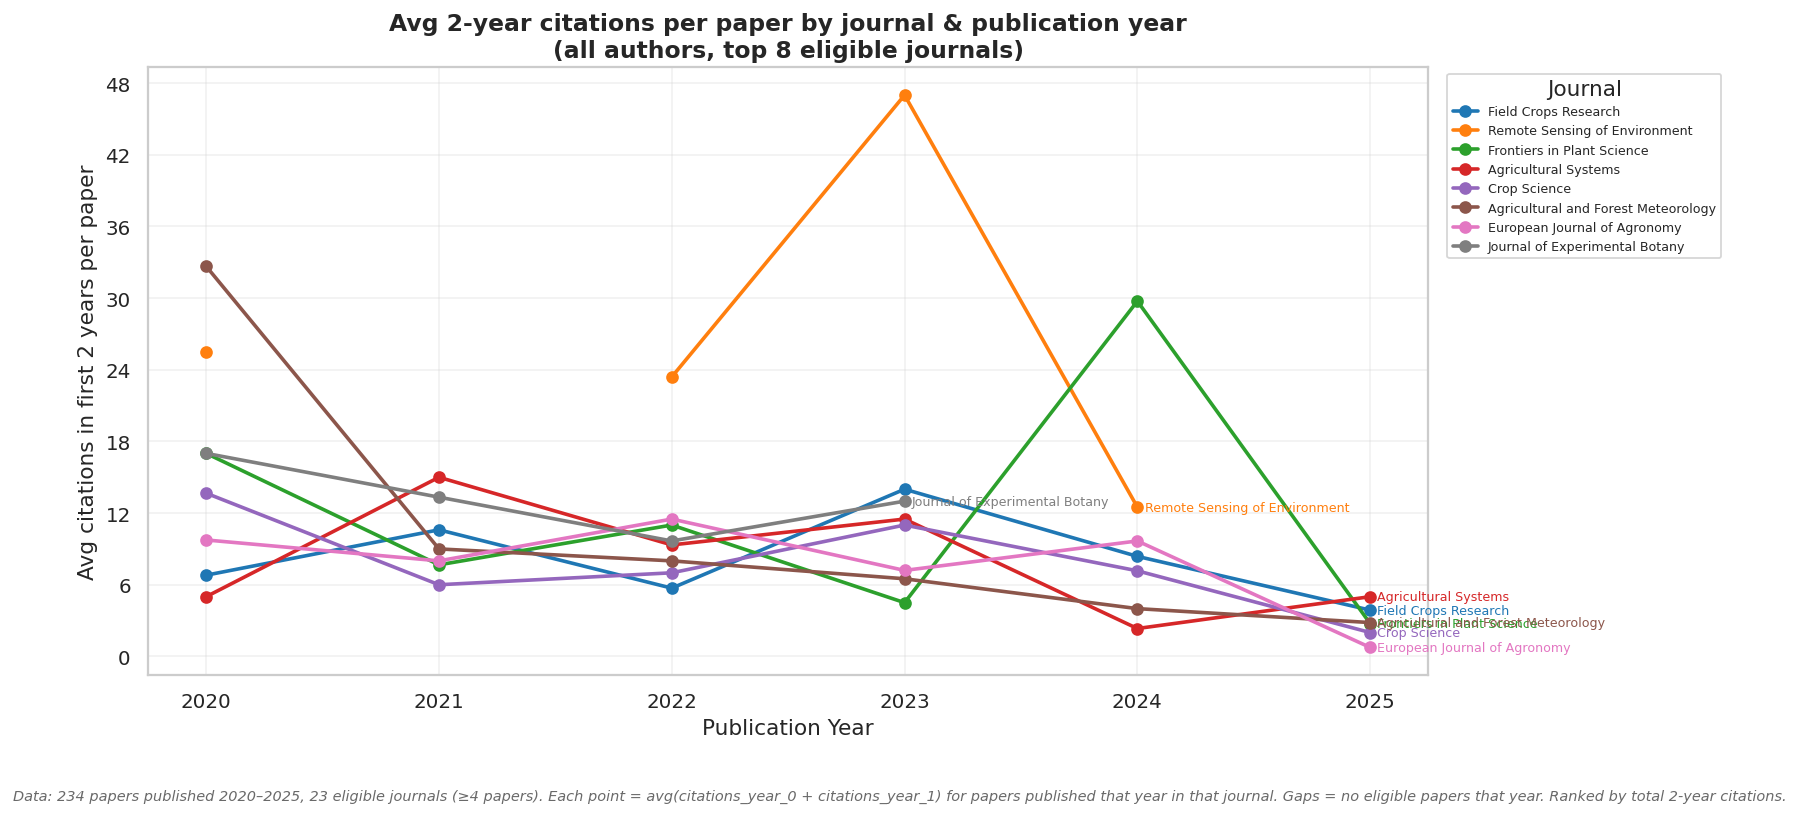

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 (all authors) — Avg 2-yr citations per paper by journal & pub year
# Best for spotting which journals consistently produce high-impact papers
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, matplotlib.ticker as mticker

PLOT_START = 2020; PLOT_END = 2025; TOP_N = 8
JOURNAL_COL = "journal_display_name"

df = filtered_all_df_corr.copy()
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")
df["cit_2yr"] = (
    pd.to_numeric(df["citations_year_0"], errors="coerce").fillna(0)
    + pd.to_numeric(df["citations_year_1"], errors="coerce").fillna(0)
)

paper = (
    df[["article_id", JOURNAL_COL, "publication_year", "cit_2yr"]]
    .dropna(subset=[JOURNAL_COL, "publication_year"])
    .drop_duplicates(subset="article_id")
)
paper = paper[(paper["publication_year"] >= PLOT_START) & (paper["publication_year"] <= PLOT_END)]

jnl_counts = df.dropna(subset=[JOURNAL_COL]).groupby(JOURNAL_COL)["article_id"].nunique()
min_papers  = int(np.floor(jnl_counts.mean())) + 1
eligible    = jnl_counts[jnl_counts >= min_papers].index
paper       = paper[paper[JOURNAL_COL].isin(eligible)]

stats_df = (
    paper.groupby([JOURNAL_COL, "publication_year"])
    .agg(total_cit_2yr=("cit_2yr", "sum"), n_papers=("article_id", "nunique"))
    .reset_index()
)
stats_df["avg_cit_2yr"] = stats_df["total_cit_2yr"] / stats_df["n_papers"].clip(lower=1)

top_journals = (
    stats_df.groupby(JOURNAL_COL)["total_cit_2yr"].sum()
    .nlargest(TOP_N).index.tolist()
)
stats_df = stats_df[stats_df[JOURNAL_COL].isin(top_journals)]

full_idx = pd.MultiIndex.from_product([top_journals, range(PLOT_START, PLOT_END + 1)],
                                       names=[JOURNAL_COL, "publication_year"])
stats_df = stats_df.set_index([JOURNAL_COL, "publication_year"]).reindex(full_idx).reset_index()

palette   = sns.color_palette("tab10", n_colors=TOP_N)
jnl_color = dict(zip(top_journals, palette))

fig, ax = plt.subplots(figsize=(13, 6))
for journal in top_journals:
    grp  = stats_df[stats_df[JOURNAL_COL] == journal].sort_values("publication_year")
    ax.plot(grp["publication_year"], grp["avg_cit_2yr"], marker="o",
            linewidth=2, label=journal, color=jnl_color[journal])
    last = grp.dropna(subset=["avg_cit_2yr"])
    if not last.empty:
        r = last.iloc[-1]
        ax.annotate(journal, xy=(r["publication_year"], r["avg_cit_2yr"]),
                    xytext=(4, 0), textcoords="offset points",
                    fontsize=7, color=jnl_color[journal], va="center")

ax.set_title(f"Avg 2-year citations per paper by journal & publication year\n(all authors, top {TOP_N} eligible journals)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Avg citations in first 2 years per paper")
ax.set_xticks(range(PLOT_START, PLOT_END + 1))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title="Journal", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)
ax.grid(alpha=0.25)

note = (
    f"Data: {paper['article_id'].nunique()} papers published {PLOT_START}–{PLOT_END}, "
    f"{len(eligible)} eligible journals (≥{min_papers} papers). "
    "Each point = avg(citations_year_0 + citations_year_1) for papers published that year in that journal. "
    "Gaps = no eligible papers that year. Ranked by total 2-year citations."
)
fig.text(0.5, -0.04, note, ha="center", fontsize=8, color="dimgray", style="italic")
plt.tight_layout(); plt.subplots_adjust(bottom=0.12)
plt.show()

IndexError: tuple index out of range

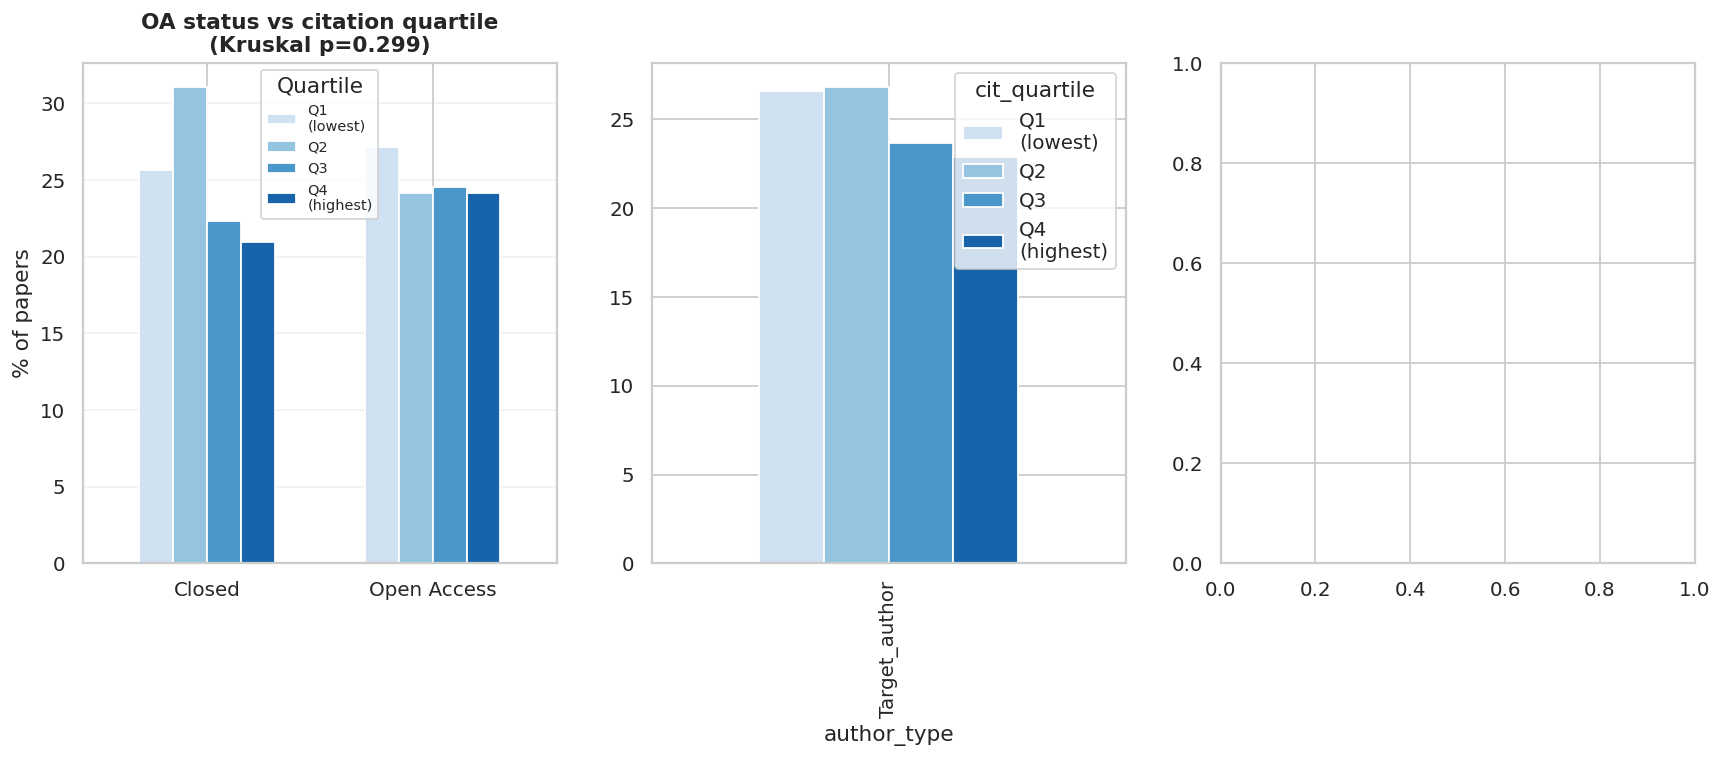

In [ ]:
# # ══════════════════════════════════════════════════════════════════════════════
# # CELL 6 (all authors) — What makes a paper cited more?
# # Compares OA status, author position, author type, and topic/journal
# # across citation quartiles. The most direct answer to the core question.
# # ══════════════════════════════════════════════════════════════════════════════
# import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# from scipy.stats import kruskal

# TOPIC_COL   = "primary_topic"
# JOURNAL_COL = "journal_display_name"

# df = filtered_all_df_corr.copy()
# df["cit_2yr"] = (
#     pd.to_numeric(df["citations_year_0"], errors="coerce").fillna(0)
#     + pd.to_numeric(df["citations_year_1"], errors="coerce").fillna(0)
# )
# df = df.dropna(subset=["cit_2yr"]).drop_duplicates(subset="article_id")
# df["cit_quartile"] = pd.qcut(df["cit_2yr"], q=4, labels=["Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)"])

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# palette_q  = sns.color_palette("Blues", n_colors=4)

# # --- Panel A: Open Access vs citations ----------------------------------------
# oa_med = df.groupby(["is_oa", "cit_quartile"]).size().unstack("cit_quartile").fillna(0)
# oa_pct = oa_med.div(oa_med.sum(axis=1), axis=0) * 100
# oa_pct.index = ["Closed", "Open Access"]
# oa_pct.plot(kind="bar", ax=axes[0], color=palette_q, edgecolor="white", width=0.6)
# axes[0].set_title("OA status vs citation quartile", fontweight="bold")
# axes[0].set_ylabel("% of papers")
# axes[0].set_xlabel("")
# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
# axes[0].legend(title="Quartile", fontsize=8)
# axes[0].grid(axis="y", alpha=0.25)
# oa_groups  = [df[df["is_oa"] == v]["cit_2yr"].values for v in [True, False]]
# _, p_oa    = kruskal(*[g for g in oa_groups if len(g) > 0])
# axes[0].set_title(f"OA status vs citation quartile\n(Kruskal p={p_oa:.3f})", fontweight="bold")

# # --- Panel B: Author type vs citations ----------------------------------------
# if "author_type" in df.columns:
#     at_med = df.groupby(["author_type", "cit_quartile"]).size().unstack("cit_quartile").fillna(0)
#     at_pct = at_med.div(at_med.sum(axis=1), axis=0) * 100
#     at_pct.plot(kind="bar", ax=axes[1], color=palette_q, edgecolor="white", width=0.6)
#     at_groups = [df[df["author_type"] == v]["cit_2yr"].values
#                  for v in df["author_type"].dropna().unique()]
#     _, p_at   = kruskal(*[g for g in at_groups if len(g) > 0])
#     axes[1].set_title(f"Author type vs citation quartile\n(Kruskal p={p_at:.3f})", fontweight="bold")
#     axes[1].set_ylabel("% of papers")
#     axes[1].set_xlabel("")
#     axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
#     axes[1].legend(title="Quartile", fontsize=8)
#     axes[1].grid(axis="y", alpha=0.25)

# # --- Panel C: Author position vs citations ------------------------------------
# if "author_position" in df.columns:
#     pos_order = ["first", "middle", "last"]
#     pos_df    = df[df["author_position"].isin(pos_order)].copy()
#     pos_med   = pos_df.groupby(["author_position", "cit_quartile"]).size().unstack("cit_quartile").fillna(0)
#     pos_pct   = pos_med.div(pos_med.sum(axis=1), axis=0) * 100
#     pos_pct   = pos_pct.reindex(pos_order)
#     pos_pct.plot(kind="bar", ax=axes[2], color=palette_q, edgecolor="white", width=0.6)
#     pos_groups = [pos_df[pos_df["author_position"] == v]["cit_2yr"].values for v in pos_order]
#     _, p_pos   = kruskal(*[g for g in pos_groups if len(g) > 0])
#     axes[2].set_title(f"Author position vs citation quartile\n(Kruskal p={p_pos:.3f})", fontweight="bold")
#     axes[2].set_ylabel("% of papers")
#     axes[2].set_xlabel("")
#     axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
#     axes[2].legend(title="Quartile", fontsize=8)
#     axes[2].grid(axis="y", alpha=0.25)

# plt.suptitle("What makes a paper cited more? — All authors", fontsize=14, fontweight="bold", y=1.02)

# note = (
#     f"Data: {df['article_id'].nunique()} unique papers, all authors. "
#     "2-year citations = citations_year_0 + citations_year_1. "
#     "Quartiles split the full citation distribution into 4 equal groups. "
#     "Bars show % of papers from each group falling in each citation quartile. "
#     "Kruskal-Wallis p-value tests whether citation distributions differ significantly across groups."
# )
# fig.text(0.5, -0.04, note, ha="center", fontsize=8, color="dimgray", style="italic")
# plt.tight_layout(); plt.subplots_adjust(bottom=0.1)
# plt.show()

# # Print median 2-yr citations by group
# for col in ["is_oa", "author_type", "author_position"]:
#     if col in df.columns:
#         print(f"\nMedian 2-yr citations by {col}:")
#         print(df.groupby(col)["cit_2yr"].median().sort_values(ascending=False).to_string())